# Day 7: Testing tree-based models

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import ConfusionMatrixDisplay

## Loading Data

In [6]:
df = pd.read_csv("../data/processed/matchup_training_data.csv")

In [9]:
features = [
    "last_5_points_per_match_diff",
    "last_5_goals_for_per_match_diff",
    "last_5_goals_against_per_match_diff",
    "last_5_goal_difference_per_match_diff",
    "last_5_win_diff",
    "last_5_draw_diff",
    "last_5_loss_diff"
]

target = "target"

In [10]:
df["date"] = pd.to_datetime(df["date"])

In [11]:
train_df = df[df["date"] < "2018-01-01"].copy()
test_df = df[df["date"] >= "2018-01-01"].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTest distribution:")
print(y_test.value_counts())

Train size: 41299
Test size: 8155

Test distribution:
target
win     3862
loss    2359
draw    1934
Name: count, dtype: int64


## Defining Models

In [12]:
models = {
    "random_forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

## Training/Evaluating Models

In [13]:
results = []

for name, model in models.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    pred_counts = pd.Series(y_pred).value_counts()

    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

    print("\nPrediction counts:")
    print(pred_counts)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=["win", "draw", "loss"]))

    results.append({
        "model": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "win_f1": report["win"]["f1-score"],
        "draw_f1": report["draw"]["f1-score"],
        "loss_f1": report["loss"]["f1-score"],
        "predicted_wins": pred_counts.get("win", 0),
        "predicted_draws": pred_counts.get("draw", 0),
        "predicted_losses": pred_counts.get("loss", 0)
    })

random_forest
Accuracy: 0.44782342121397917
Macro F1: 0.42614616430434343
Weighted F1: 0.457482142758343

Prediction counts:
win     3254
draw    2491
loss    2410
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw       0.25      0.32      0.28      1934
        loss       0.43      0.44      0.44      2359
         win       0.61      0.51      0.56      3862

    accuracy                           0.45      8155
   macro avg       0.43      0.43      0.43      8155
weighted avg       0.47      0.45      0.46      8155


Confusion matrix:
[[1978 1120  764]
 [ 706  628  600]
 [ 570  743 1046]]
gradient_boosting
Accuracy: 0.5288779889638259
Macro F1: 0.36497218589547814
Weighted F1: 0.43903871095036556

Prediction counts:
win     6604
loss    1539
draw      12
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw       0.67      0.00      0.01      1934
   

## Visualizing Results

In [14]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
)

results_df

,model,accuracy,macro_f1,weighted_f1,win_f1,draw_f1,loss_f1,predicted_wins,predicted_draws,predicted_losses
0,random_forest,0.447823,0.426146,0.457482,0.555930,0.283842,0.438666,3254,2491,2410
1,gradient_boosting,0.528878,0.364972,0.439039,0.665966,0.008222,0.420729,6604,12,1539
2,hist_gradient_boosting,0.524464,0.359827,0.434101,0.663107,0.007191,0.409185,6625,13,1517


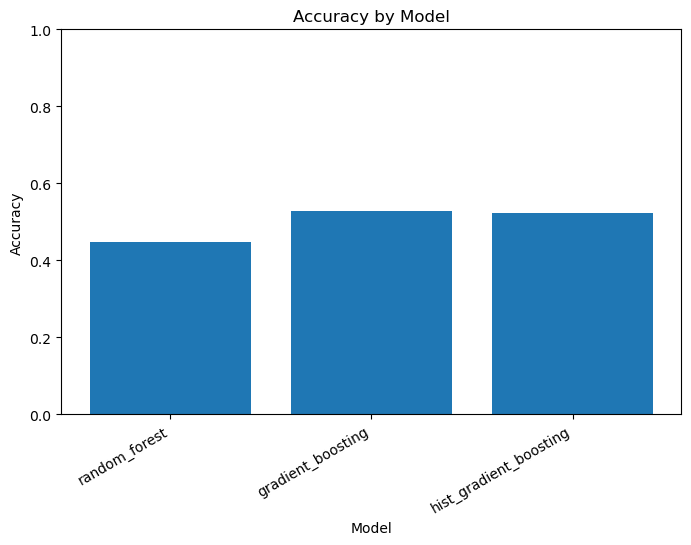

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["model"], results_df["accuracy"])

plt.title("Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.show()

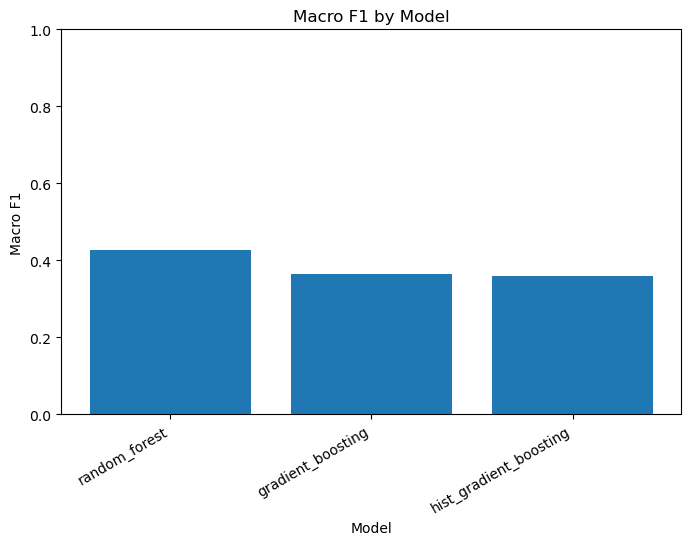

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["model"], results_df["macro_f1"])

plt.title("Macro F1 by Model")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.show()

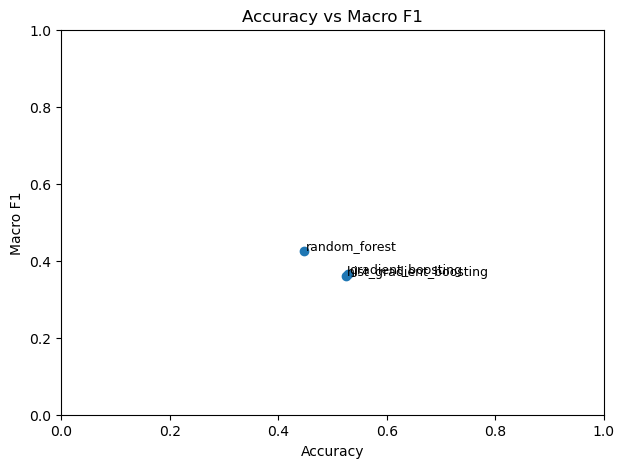

In [22]:
plt.figure(figsize=(7, 5))

plt.scatter(results_df["accuracy"], results_df["macro_f1"])

for i, row in results_df.iterrows():
    plt.text(
        row["accuracy"] + 0.002,
        row["macro_f1"] + 0.002,
        row["model"],
        fontsize=9
    )

plt.title("Accuracy vs Macro F1")
plt.xlabel("Accuracy")
plt.ylabel("Macro F1")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

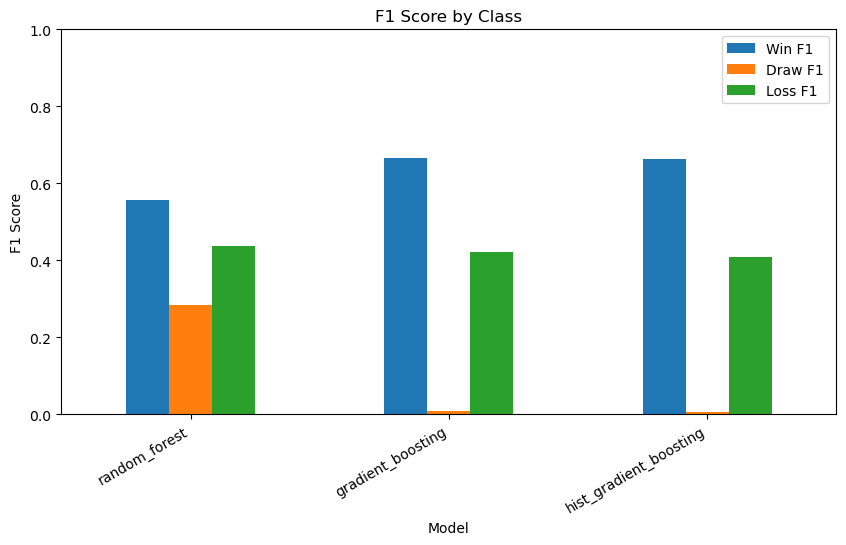

In [23]:
class_f1_df = results_df[
    ["model", "win_f1", "draw_f1", "loss_f1"]
].copy()

class_f1_df.plot(
    x="model",
    kind="bar",
    figsize=(10, 5)
)

plt.title("F1 Score by Class")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(["Win F1", "Draw F1", "Loss F1"])

plt.show()

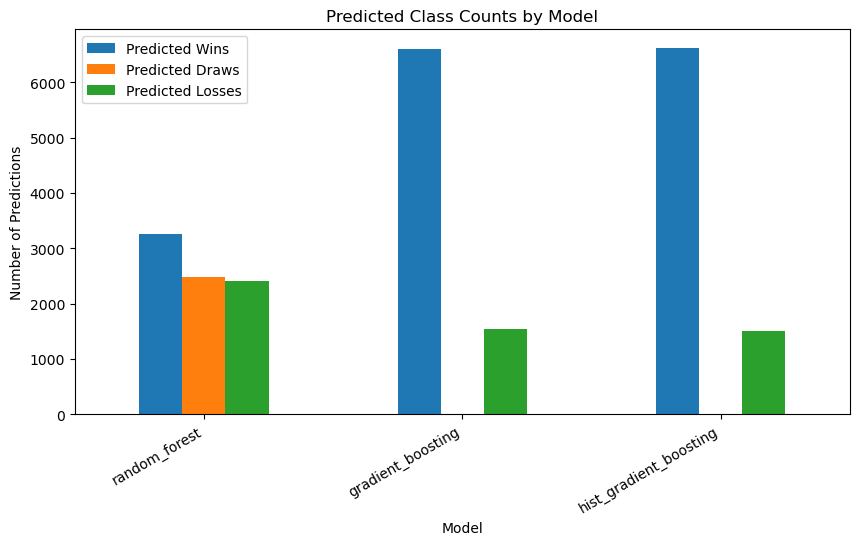

In [24]:
prediction_counts_df = results_df[
    ["model", "predicted_wins", "predicted_draws", "predicted_losses"]
].copy()

prediction_counts_df.plot(
    x="model",
    kind="bar",
    figsize=(10, 5)
)

plt.title("Predicted Class Counts by Model")
plt.xlabel("Model")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=30, ha="right")
plt.legend(["Predicted Wins", "Predicted Draws", "Predicted Losses"])

plt.show()

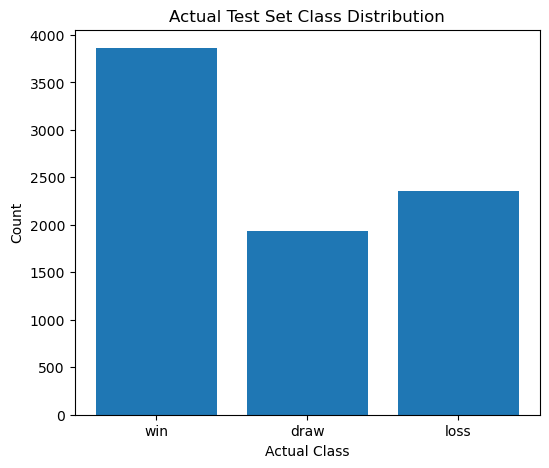

In [25]:
actual_counts = y_test.value_counts().reindex(["win", "draw", "loss"])

plt.figure(figsize=(6, 5))

plt.bar(actual_counts.index, actual_counts.values)

plt.title("Actual Test Set Class Distribution")
plt.xlabel("Actual Class")
plt.ylabel("Count")

plt.show()

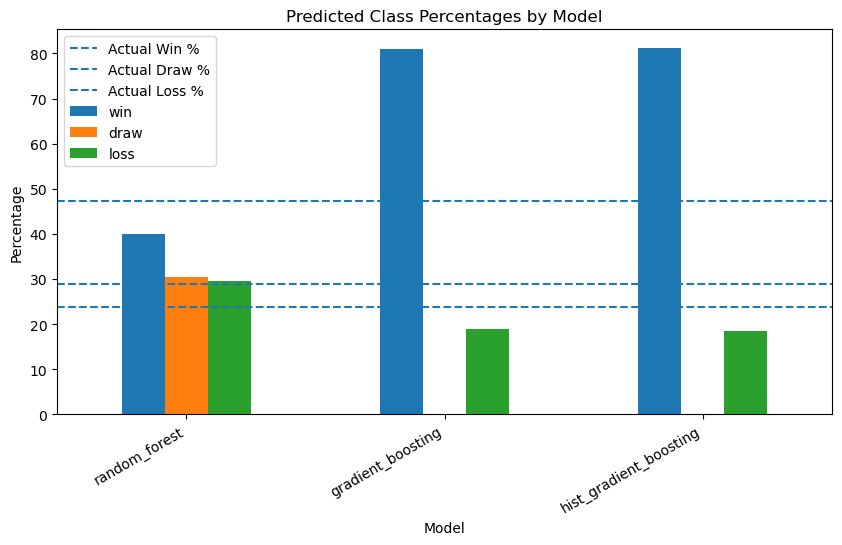

In [27]:
actual_percentages = y_test.value_counts(normalize=True).reindex(["win", "draw", "loss"]) * 100

predicted_percentages = []

for _, row in results_df.iterrows():
    total_preds = (
        row["predicted_wins"] 
        + row["predicted_draws"] 
        + row["predicted_losses"]
    )

    predicted_percentages.append({
        "model": row["model"],
        "win": row["predicted_wins"] / total_preds * 100,
        "draw": row["predicted_draws"] / total_preds * 100,
        "loss": row["predicted_losses"] / total_preds * 100
    })

predicted_percentages_df = pd.DataFrame(predicted_percentages)

predicted_percentages_df.plot(
    x="model",
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(actual_percentages["win"], linestyle="--", label="Actual Win %")
plt.axhline(actual_percentages["draw"], linestyle="--", label="Actual Draw %")
plt.axhline(actual_percentages["loss"], linestyle="--", label="Actual Loss %")

plt.title("Predicted Class Percentages by Model")
plt.xlabel("Model")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.legend()

plt.show()

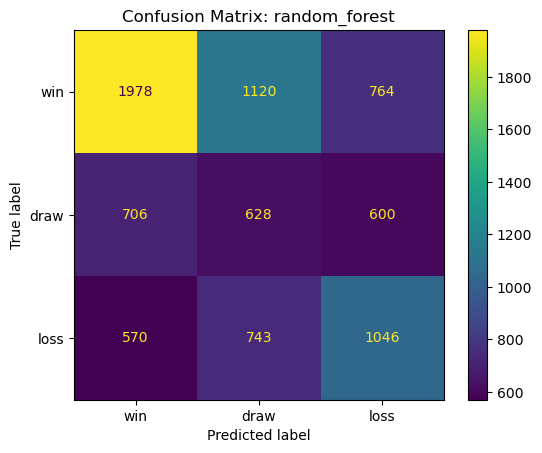

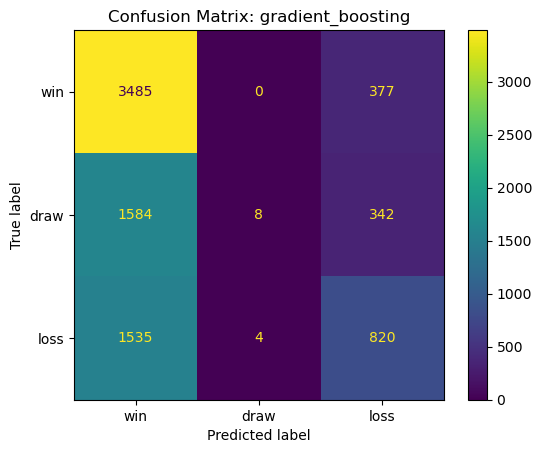

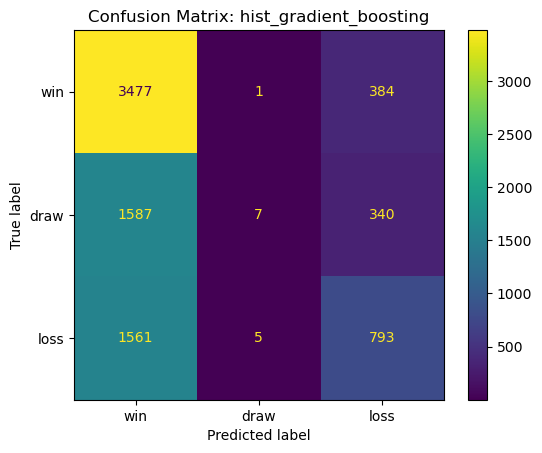

In [29]:
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

labels = ["win", "draw", "loss"]

for name, y_pred in predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=labels,
        display_labels=labels,
        values_format="d"
    )

    plt.title(f"Confusion Matrix: {name}")
    plt.show()

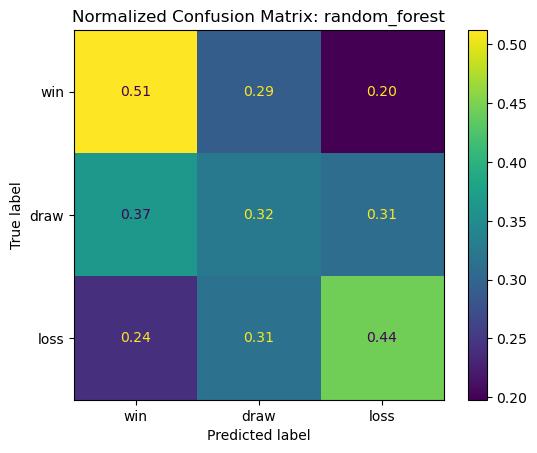

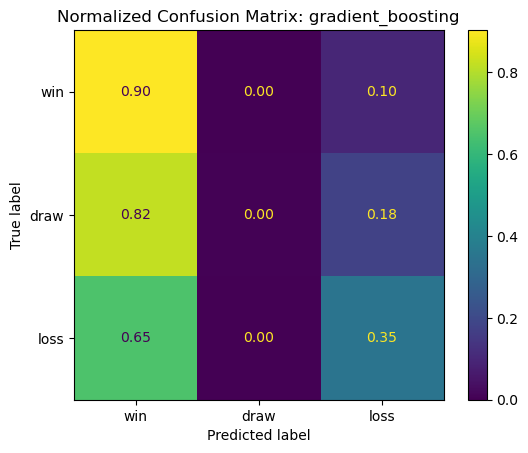

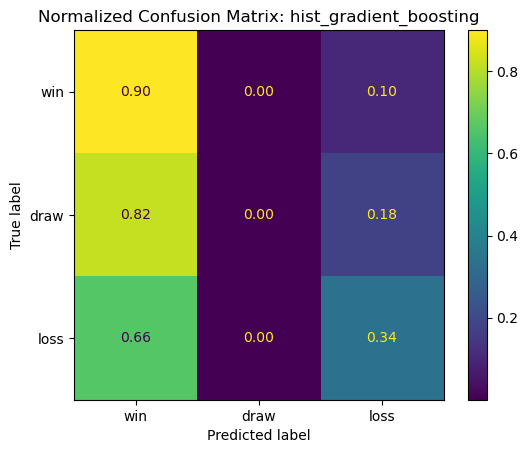

In [30]:
labels = ["win", "draw", "loss"]

for name, y_pred in predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=labels,
        display_labels=labels,
        normalize="true",
        values_format=".2f"
    )

    plt.title(f"Normalized Confusion Matrix: {name}")
    plt.show()

## Incorporating Class Balancing

In [31]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [41]:
balanced_tree_models = {
    "gradient_boosting_balanced": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "hist_gradient_boosting_balanced": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

In [42]:
balanced_results = []

for name, model in balanced_tree_models.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    pred_counts = pd.Series(y_pred).value_counts()

    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

    print("\nPrediction counts:")
    print(pred_counts)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=["win", "draw", "loss"]))

    balanced_results.append({
        "model": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "win_f1": report["win"]["f1-score"],
        "draw_f1": report["draw"]["f1-score"],
        "loss_f1": report["loss"]["f1-score"],
        "predicted_wins": pred_counts.get("win", 0),
        "predicted_draws": pred_counts.get("draw", 0),
        "predicted_losses": pred_counts.get("loss", 0)
    })

gradient_boosting_balanced
Accuracy: 0.4576333537706928
Macro F1: 0.44487134094958664
Weighted F1: 0.4716136249015808

Prediction counts:
win     2917
draw    2892
loss    2346
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw       0.26      0.39      0.31      1934
        loss       0.47      0.47      0.47      2359
         win       0.64      0.49      0.55      3862

    accuracy                           0.46      8155
   macro avg       0.46      0.45      0.44      8155
weighted avg       0.50      0.46      0.47      8155


Confusion matrix:
[[1874 1313  675]
 [ 607  757  570]
 [ 436  822 1101]]
hist_gradient_boosting_balanced
Accuracy: 0.4581238503985285
Macro F1: 0.44437782277426874
Weighted F1: 0.4715686708907614

Prediction counts:
win     2963
draw    2824
loss    2368
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

        draw       0.26      0.

In [43]:
balanced_results_df = pd.DataFrame(balanced_results)

all_results_df = pd.concat(
    [results_df, balanced_results_df],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
)

all_results_df

,model,accuracy,macro_f1,weighted_f1,win_f1,draw_f1,loss_f1,predicted_wins,predicted_draws,predicted_losses
3,gradient_boosting_balanced,0.457633,0.444871,0.471614,0.552884,0.313717,0.468013,2917,2892,2346
4,hist_gradient_boosting_balanced,0.458124,0.444378,0.471569,0.553260,0.307692,0.472181,2963,2824,2368
0,random_forest,0.447823,0.426146,0.457482,0.555930,0.283842,0.438666,3254,2491,2410
1,gradient_boosting,0.528878,0.364972,0.439039,0.665966,0.008222,0.420729,6604,12,1539
2,hist_gradient_boosting,0.524464,0.359827,0.434101,0.663107,0.007191,0.409185,6625,13,1517


## Comparing to Logistic Regression Models

In [44]:
logistic_models = {
    "logistic_normal": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "logistic_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "logistic_medium_draw_boost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight={
                "win": 1,
                "loss": 1,
                "draw": 2
            },
            random_state=42
        ))
    ])
}

In [45]:
logistic_results = []

for name, model in logistic_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    pred_counts = pd.Series(y_pred).value_counts()

    logistic_results.append({
        "model": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "win_f1": report["win"]["f1-score"],
        "draw_f1": report["draw"]["f1-score"],
        "loss_f1": report["loss"]["f1-score"],
        "predicted_wins": pred_counts.get("win", 0),
        "predicted_draws": pred_counts.get("draw", 0),
        "predicted_losses": pred_counts.get("loss", 0)
    })

In [46]:
logistic_results_df = pd.DataFrame(logistic_results)

final_results_df = pd.concat(
    [logistic_results_df, all_results_df],
    ignore_index=True
)

final_results_df = final_results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
)

final_results_df[
    [
        "model",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "win_f1",
        "draw_f1",
        "loss_f1",
        "predicted_wins",
        "predicted_draws",
        "predicted_losses"
    ]
]

,model,accuracy,macro_f1,weighted_f1,win_f1,draw_f1,loss_f1,predicted_wins,predicted_draws,predicted_losses
3,gradient_boosting_balanced,0.457633,0.444871,0.471614,0.552884,0.313717,0.468013,2917,2892,2346
4,hist_gradient_boosting_balanced,0.458124,0.444378,0.471569,0.553260,0.307692,0.472181,2963,2824,2368
1,logistic_balanced,0.490374,0.443977,0.484856,0.606149,0.233083,0.492699,3717,1524,2914
5,random_forest,0.447823,0.426146,0.457482,0.555930,0.283842,0.438666,3254,2491,2410
2,logistic_medium_draw_boost,0.467566,0.395660,0.442612,0.635437,0.342705,0.208838,4378,3330,447
6,gradient_boosting,0.528878,0.364972,0.439039,0.665966,0.008222,0.420729,6604,12,1539
0,logistic_normal,0.525812,0.361060,0.435600,0.663407,0.000000,0.419772,6569,0,1586
7,hist_gradient_boosting,0.524464,0.359827,0.434101,0.663107,0.007191,0.409185,6625,13,1517
